In [1]:
import torch
import numpy as np
import syft as sy
import torch.nn as nn
import pandas as pd
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset as FederatedDataset
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score, mean_absolute_error

unsupported operand type(s) for |: 'type' and 'NoneType'


C:\Users\ek\miniconda3\envs\help\lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,


In [2]:
url = 'https://raw.githubusercontent.com/samhithanair/Energy-Consumption-Using-LSTM-and-Federated-Learning/main/Household_electricity_dataset%202020-2024.csv'
df = pd.read_csv(url)

In [3]:
df

,Date,Value,Day,Temp_max,Temp_avg,Temp_min,Dew_max,Dew_avg,Dew_min,Hum_max,...,Hum_min,Wind_max,Wind_avg,Wind_min,Press_max,Press_avg,Press_min,Precipitation,day_of_week,Day.1
0,07-08-2020,24.752,1,85,73.8,68,74,71.4,66,100,...,65,21,9.5,0,29.8,29.8,29.7,0.00,2,1
1,07-09-2020,13.892,2,76,71.2,66,74,70.3,66,100,...,89,18,7.8,0,29.8,29.8,29.7,4.33,5,2
2,07-10-2020,17.166,3,79,72.1,68,73,70.0,68,100,...,72,18,4.7,0,29.8,29.8,29.7,3.18,6,3
3,07-11-2020,12.173,4,76,71.2,69,73,70.0,66,100,...,85,20,7.0,0,29.8,29.7,29.7,2.37,2,4
4,07-12-2020,42.250,5,82,73.8,68,72,70.0,68,100,...,62,17,7.7,0,29.7,29.7,29.7,0.39,4,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1493,08-09-2024,28.431,3,96,84.7,74,76,72.8,67,91,...,38,24,6.3,0,29.9,29.9,29.8,0.00,5,1494
1494,08-10-2024,12.699,4,97,84.6,73,76,72.9,70,94,...,43,10,3.6,0,29.9,29.8,29.7,0.00,1,1495
1495,08-11-2024,24.830,5,95,85.4,79,75,73.5,68,88,...,44,12,6.2,0,29.8,29.7,29.7,0.00,3,1496
1496,08-12-2024,27.965,6,91,85.5,82,77,75.5,72,82,...,59,10,6.0,0,29.8,29.8,29.7,0.00,6,1497


In [4]:
df_numeric = df.select_dtypes(include=[np.number])

In [5]:
X = df_numeric.drop(columns=['Value'])
y = df_numeric['Value']

In [6]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
split_idx1 = len(X_scaled) // 3
split_idx2 = 2 * len(X_scaled) // 3

In [8]:
X_c1 = X_scaled[:split_idx1]
X_c2 = X_scaled[split_idx1:split_idx2]
X_c3 = X_scaled[split_idx2:]

In [9]:
y_c1 = y[:split_idx1].values.reshape(-1, 1)
y_c2 = y[split_idx1:split_idx2].values.reshape(-1, 1)
y_c3 = y[split_idx2:].values.reshape(-1, 1)

In [10]:
X_c1_tensor = torch.tensor(X_c1, dtype=torch.float32)
X_c2_tensor = torch.tensor(X_c2, dtype=torch.float32)
X_c3_tensor = torch.tensor(X_c3, dtype=torch.float32)

y_c1_tensor = torch.tensor(y_c1, dtype=torch.float32)
y_c2_tensor = torch.tensor(y_c2, dtype=torch.float32)
y_c3_tensor = torch.tensor(y_c3, dtype=torch.float32)

In [11]:
dataset_c1 = FederatedDataset(X_c1_tensor, y_c1_tensor)
dataset_c2 = FederatedDataset(X_c2_tensor, y_c2_tensor)
dataset_c3 = FederatedDataset(X_c3_tensor, y_c3_tensor)

In [12]:
batch_size = 64

In [13]:
dataloader_c1 = DataLoader(dataset_c1, batch_size=batch_size, shuffle=True)
dataloader_c2 = DataLoader(dataset_c2, batch_size=batch_size, shuffle=True)
dataloader_c3 = DataLoader(dataset_c3, batch_size=batch_size, shuffle=True)

In [14]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(1, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(1, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

In [15]:
input_size = X_c1_tensor.shape[1]
hidden_size = 16
output_size = 1
input_size

19

In [16]:
model = LSTMModel(input_size, hidden_size, output_size)
model_c1 = LSTMModel(input_size, hidden_size, output_size)
model_c2 = LSTMModel(input_size, hidden_size, output_size)
model_c3 = LSTMModel(input_size, hidden_size, output_size)

In [17]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [18]:
import matplotlib.pyplot as plt

def train(model,dataloader):
    epochs = 1000
    loss_values = []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for data in [dataloader_c1]:
            for inputs, labels in data:
                optimizer.zero_grad()
                outputs = model(inputs.unsqueeze(1))
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                running_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {running_loss*0.0001}")
        loss_values.append(running_loss*0.0001)
    
    plt.plot(loss_values)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.show()

Epoch 1, Loss: 1.0163642333984375
Epoch 2, Loss: 1.0164893432617188
Epoch 3, Loss: 1.0220346801757814
Epoch 4, Loss: 1.0183226196289064
Epoch 5, Loss: 1.0204260864257813
Epoch 6, Loss: 1.0197888427734376
Epoch 7, Loss: 1.01746015625
Epoch 8, Loss: 1.015642236328125
Epoch 9, Loss: 1.0158916381835938
Epoch 10, Loss: 1.017921697998047
Epoch 11, Loss: 1.0182124267578125
Epoch 12, Loss: 1.0162302612304688
Epoch 13, Loss: 1.016308483886719
Epoch 14, Loss: 1.02070595703125
Epoch 15, Loss: 1.0208566284179688
Epoch 16, Loss: 1.0210629638671875
Epoch 17, Loss: 1.0202085327148438
Epoch 18, Loss: 1.018873583984375
Epoch 19, Loss: 1.0167262329101563
Epoch 20, Loss: 1.01664052734375
Epoch 21, Loss: 1.018963037109375
Epoch 22, Loss: 1.0165720336914064
Epoch 23, Loss: 1.017552685546875
Epoch 24, Loss: 1.01979912109375
Epoch 25, Loss: 1.0148715576171876
Epoch 26, Loss: 1.0184446655273438
Epoch 27, Loss: 1.0231848571777344
Epoch 28, Loss: 1.017113134765625
Epoch 29, Loss: 1.0179068603515626
Epoch 30, Lo

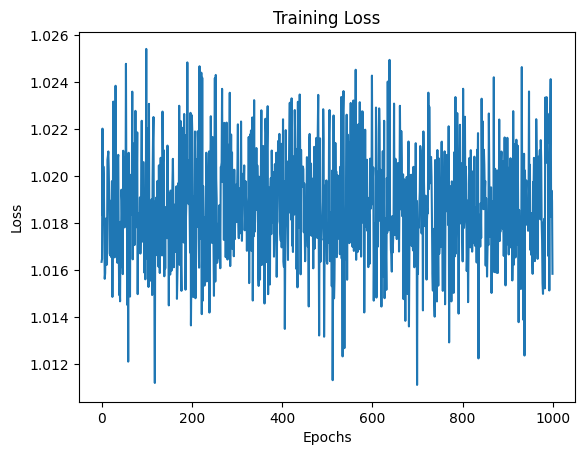

CPU times: total: 32.6 s
Wall time: 30.8 s


In [19]:
%%time
train(model_c1,dataloader_c1)

Epoch 1, Loss: 0.9980648315429688
Epoch 2, Loss: 0.9962964111328125
Epoch 3, Loss: 0.9948444335937501
Epoch 4, Loss: 0.9988217529296876
Epoch 5, Loss: 0.9966094482421876
Epoch 6, Loss: 0.995633203125
Epoch 7, Loss: 0.9955751586914063
Epoch 8, Loss: 0.9954673767089844
Epoch 9, Loss: 0.9968672729492188
Epoch 10, Loss: 0.998178955078125
Epoch 11, Loss: 0.9940619506835938
Epoch 12, Loss: 1.0018124877929688
Epoch 13, Loss: 0.9915676330566406
Epoch 14, Loss: 0.9951951049804688
Epoch 15, Loss: 0.9988627380371095
Epoch 16, Loss: 0.9966917358398438
Epoch 17, Loss: 0.9990084594726563
Epoch 18, Loss: 1.0010393188476563
Epoch 19, Loss: 0.9974341430664063
Epoch 20, Loss: 0.9944649536132812
Epoch 21, Loss: 0.9943449462890626
Epoch 22, Loss: 0.998478955078125
Epoch 23, Loss: 1.001424792480469
Epoch 24, Loss: 0.9986905517578125
Epoch 25, Loss: 0.9962660766601563
Epoch 26, Loss: 0.9962093139648438
Epoch 27, Loss: 0.9966395751953125
Epoch 28, Loss: 0.9969396850585938
Epoch 29, Loss: 0.9967479980468751
E

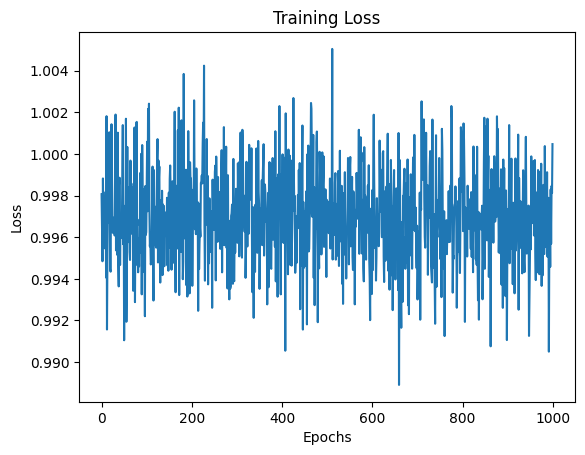

CPU times: total: 30.1 s
Wall time: 30.9 s


In [21]:
%%time
train(model_c2,dataloader_c2)

Epoch 1, Loss: 1.0146484252929688
Epoch 2, Loss: 1.0185496337890625
Epoch 3, Loss: 1.0199917358398438
Epoch 4, Loss: 1.0207253417968751
Epoch 5, Loss: 1.0168466918945314
Epoch 6, Loss: 1.0199429687500001
Epoch 7, Loss: 1.018391357421875
Epoch 8, Loss: 1.0193097045898438
Epoch 9, Loss: 1.0213680419921876
Epoch 10, Loss: 1.0153252319335937
Epoch 11, Loss: 1.0184654663085937
Epoch 12, Loss: 1.0180158325195312
Epoch 13, Loss: 1.0156225463867188
Epoch 14, Loss: 1.0177297973632813
Epoch 15, Loss: 1.0130286254882812
Epoch 16, Loss: 1.0116197570800782
Epoch 17, Loss: 1.0166919677734376
Epoch 18, Loss: 1.0166615600585938
Epoch 19, Loss: 1.0187189819335938
Epoch 20, Loss: 1.0204477172851563
Epoch 21, Loss: 1.0166127319335938
Epoch 22, Loss: 1.0156271606445313
Epoch 23, Loss: 1.0169666137695312
Epoch 24, Loss: 1.0171337158203126
Epoch 25, Loss: 1.0137124877929689
Epoch 26, Loss: 1.0151388305664062
Epoch 27, Loss: 1.01954267578125
Epoch 28, Loss: 1.0171798461914063
Epoch 29, Loss: 1.01859613037109

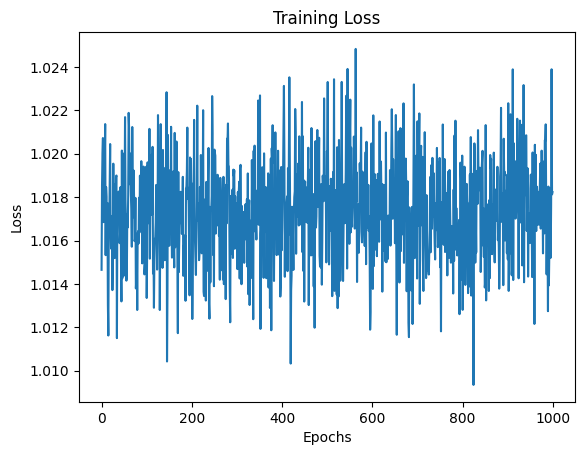

CPU times: total: 37.9 s
Wall time: 31.1 s


In [22]:
%%time
train(model_c3,dataloader_c3)

In [23]:
def predict(model, dataloader):
    model.eval()
    predictions = []
    with torch.no_grad():
        for inputs, labels in dataloader:
            outputs = model(inputs.unsqueeze(1))
            predictions.append(outputs.detach().numpy())
    return np.vstack(predictions)

In [24]:
predictions_c1 = predict(model_c1, dataloader_c1)
predictions_c2 = predict(model_c2, dataloader_c2)
predictions_c3 = predict(model_c3, dataloader_c3)

In [25]:
print("Predictions for dataset_c1:", predictions_c1[-1])
print("Predictions for dataset_c2:", predictions_c2[-1])
print("Predictions for dataset_c3:", predictions_c3[-1])

Predictions for dataset_c1: [-0.1589306]
Predictions for dataset_c2: [0.25666523]
Predictions for dataset_c3: [-0.13775834]


In [26]:
df_numeric_scaled = scaler.fit_transform(df_numeric)
y = df_numeric_scaled[:, -1]

yc1 = y[:split_idx1]
yc2 = y[split_idx1:split_idx2]
yc3 = y[split_idx2:]

In [27]:
predictions_c1_numpy = np.array(predictions_c1)
predictions_c2_numpy = np.array(predictions_c2)
predictions_c3_numpy = np.array(predictions_c3)

In [28]:
mse_c1 = mean_squared_error(predictions_c1_numpy, yc1)
mse_c2 = mean_squared_error(predictions_c2_numpy, yc2)
mse_c3 = mean_squared_error(predictions_c3_numpy, yc3)
print("Mean Squared Error of Client 1:", mse_c1)
print("Mean Squared Error of Client 2:", mse_c2)
print("Mean Squared Error of Client 3:", mse_c3)

Mean Squared Error of Client 1: 0.11698619160817794
Mean Squared Error of Client 2: 0.07351210017262581
Mean Squared Error of Client 3: 0.9697799119233886


In [29]:
rmse_c1 = root_mean_squared_error(predictions_c1_numpy, yc1)
rmse_c2 = root_mean_squared_error(predictions_c2_numpy, yc2)
rmse_c3 = root_mean_squared_error(predictions_c3_numpy, yc3)
print("Root Mean Squared Error of Client 1:", rmse_c1)
print("Root Mean Squared Error of Client 2:", rmse_c2)
print("Root Mean Squared Error of Client 3:", rmse_c3)

Root Mean Squared Error of Client 1: 0.34203244233285524
Root Mean Squared Error of Client 2: 0.271131149395686
Root Mean Squared Error of Client 3: 0.984774041048701


In [30]:
mae_c1 = mean_absolute_error(predictions_c1_numpy, yc1)
mae_c2 = mean_absolute_error(predictions_c2_numpy, yc2)
mae_c3 = mean_absolute_error(predictions_c3_numpy, yc3)
print("Mean Absolute Error of Client 1:", mae_c1)
print("Mean Absolute Error of Client 2:", mae_c2)
print("Mean Absolute Error of Client 3:", mae_c3)

Mean Absolute Error of Client 1: 0.3278173508200951
Mean Absolute Error of Client 2: 0.25268814766016817
Mean Absolute Error of Client 3: 0.980045750161012


In [31]:
r2_c1 = r2_score(predictions_c1_numpy, yc1)
r2_c2 = r2_score(predictions_c2_numpy, yc2)
r2_c3 = r2_score(predictions_c3_numpy, yc3)
print("R2 Score of Client 1:", r2_c1)
print("R2 Score of Client 2:", r2_c2)
print("R2 Score of Client 3:", r2_c3)

R2 Score of Client 1: -470.0597230295848
R2 Score of Client 2: -167.24961867726546
R2 Score of Client 3: -5501.07410405605


In [32]:
model_state_dict_c1 = model_c1.state_dict()
model_state_dict_c2 = model_c2.state_dict()
model_state_dict_c3 = model_c3.state_dict()

In [33]:
tensor_c1 = list(model_state_dict_c1.values())[0]
tensor_c2 = list(model_state_dict_c2.values())[0]
tensor_c3 = list(model_state_dict_c3.values())[0]

In [34]:
array_2d = np.empty((0, tensor_c3.size(1)))

for row in tensor_c3:
    row_array = row.numpy().reshape(1, -1)
    array_2d = np.vstack((array_2d, row_array))
for row in tensor_c2:
    row_array = row.numpy().reshape(1, -1)
    array_2d = np.vstack((array_2d, row_array))
for row in tensor_c1:
    row_array = row.numpy().reshape(1, -1)
    array_2d = np.vstack((array_2d, row_array))

In [35]:
tensor_2d = torch.tensor(array_2d, dtype=torch.float32)
input_size = tensor_2d.shape[1]
input_size

19

In [36]:
tensor_dataset = FederatedDataset(tensor_2d)

In [37]:
model_weights_dataloader = DataLoader(tensor_dataset, batch_size=batch_size, shuffle=True)

Epoch 1, Loss: 1.0154121704101562
Epoch 2, Loss: 1.0114603881835937
Epoch 3, Loss: 1.0018701293945314
Epoch 4, Loss: 0.9998906005859376
Epoch 5, Loss: 0.9968108764648438
Epoch 6, Loss: 0.9965861206054688
Epoch 7, Loss: 0.9876549194335938
Epoch 8, Loss: 0.9832063598632813
Epoch 9, Loss: 0.9759743652343751
Epoch 10, Loss: 0.9703334838867188
Epoch 11, Loss: 0.9570147094726563
Epoch 12, Loss: 0.9490056518554688
Epoch 13, Loss: 0.9428358764648438
Epoch 14, Loss: 0.9316408142089844
Epoch 15, Loss: 0.9200590209960938
Epoch 16, Loss: 0.9151318115234376
Epoch 17, Loss: 0.8975209350585938
Epoch 18, Loss: 0.8921447265625
Epoch 19, Loss: 0.8803645446777344
Epoch 20, Loss: 0.8718156494140625
Epoch 21, Loss: 0.8601293762207032
Epoch 22, Loss: 0.8445458557128906
Epoch 23, Loss: 0.8380911071777344
Epoch 24, Loss: 0.8246904052734375
Epoch 25, Loss: 0.8188372131347657
Epoch 26, Loss: 0.8093684387207032
Epoch 27, Loss: 0.8007926635742187
Epoch 28, Loss: 0.7909558776855469
Epoch 29, Loss: 0.78412932739257

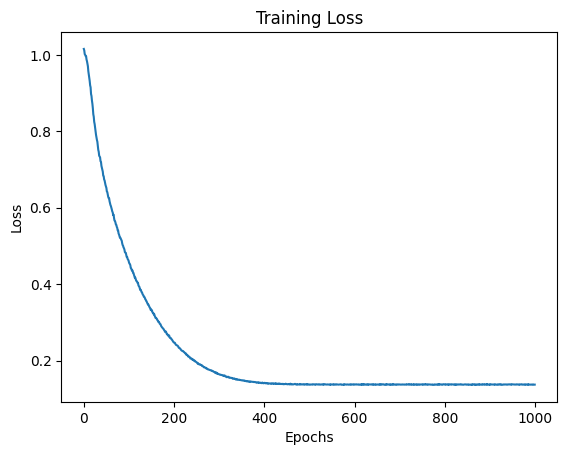

In [38]:
train(model,model_weights_dataloader)

In [39]:
def global_predict(model, dataloader):
    model.eval()
    predictions = []
    with torch.no_grad():
        for data in dataloader:
            inputs = data[0]  
            outputs = model(inputs.unsqueeze(1))
            predictions.append(outputs.detach().numpy())
    return np.vstack(predictions)

In [40]:
predictions_global = global_predict(model, model_weights_dataloader)

In [41]:
predictions_global[-1]

array([18.693756], dtype=float32)

In [46]:
y = df_numeric['Value'].values.reshape(-1, 1)

In [47]:
y_tensor = torch.tensor(y, dtype=torch.float32)

In [48]:
dataset_y = FederatedDataset(y_tensor)

In [51]:
dataloader_y = DataLoader(dataset_y, batch_size=batch_size, shuffle=True)

In [55]:
def get_gradients(model):
    gradients = {}
    for name, param in model.named_parameters():
        if param.requires_grad and param.grad is not None:
            gradients[name] = param.grad.clone().detach()
            print(f"Gradient for {name} has shape {param.grad.shape}")
    return gradients

In [56]:
gradients_y = get_gradients(model)

Gradient for lstm.weight_ih_l0 has shape torch.Size([64, 19])
Gradient for lstm.weight_hh_l0 has shape torch.Size([64, 16])
Gradient for lstm.bias_ih_l0 has shape torch.Size([64])
Gradient for lstm.bias_hh_l0 has shape torch.Size([64])
Gradient for fc.weight has shape torch.Size([1, 16])
Gradient for fc.bias has shape torch.Size([1])


In [57]:
def gradient_statistics(gradients):
    stats = {}
    for name, grad in gradients.items():
        stats[name] = {
            'mean': grad.mean().item(),
            'std': grad.std().item(),
            'max': grad.max().item(),
            'min': grad.min().item()
        }
    return stats

grad_stats = gradient_statistics(gradients_y)
print("Gradient Statistics:", grad_stats)

Gradient Statistics: {'lstm.weight_ih_l0': {'mean': 1.0470615052327048e-05, 'std': 0.00021642450883518904, 'max': 0.0013092730659991503, 'min': -0.0008584724855609238}, 'lstm.weight_hh_l0': {'mean': 0.0, 'std': 0.0, 'max': 0.0, 'min': 0.0}, 'lstm.bias_ih_l0': {'mean': 3.8398684409912676e-05, 'std': 0.00013632992340717465, 'max': 0.0003779641992878169, 'min': -0.0002596652484498918}, 'lstm.bias_hh_l0': {'mean': 3.8398684409912676e-05, 'std': 0.00013632992340717465, 'max': 0.0003779641992878169, 'min': -0.0002596652484498918}, 'fc.weight': {'mean': -0.06264419853687286, 'std': 0.25061914324760437, 'max': 0.25071531534194946, 'min': -0.2507023811340332}, 'fc.bias': {'mean': -0.3290034532546997, 'std': nan, 'max': -0.3290034532546997, 'min': -0.3290034532546997}}


C:\Users\ek\AppData\Local\Temp\ipykernel_12720\1547819943.py:6: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\ReduceOps.cpp:1807.)
  'std': grad.std().item(),
